In [220]:
import os
import pickle
import numpy as np
import os.path as osp
from tqdm import tqdm
from pprint import pprint
from datetime import datetime
from typing import List
import matplotlib.pyplot as plt

import torch
import tensorflow as tf
from tensorflow.keras import losses
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import load_model


from src.models import CNNtf
import src.cf_methods.countergan.utils  as cutils
from src.cf_methods.countergan import create_convolutional_autoencoder

tf.experimental.numpy.experimental_enable_numpy_behavior()

plt.style.use('seaborn-v0_8-darkgrid')

In [221]:
from src.utils import seed_tf

seed_tf()

Loading MNIST data

In [222]:
DESIRED_CLASS = 7  # This is the target class that the generator will learn to synthetize
N_CLASSES = 10

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = (x_train / 255.).astype("float32")
x_test = (x_test / 255.).astype("float32")

In [224]:
def get_factual_instances(x: np.ndarray, y: np.ndarray, class_indices: List[int], set_new_ind=False):
    labels = []
    factuals = []
    for new_ind, class_ind in enumerate(class_indices):
        class_mask = (y == class_ind)
        if set_new_ind:
            labels.extend(y[class_mask].shape[0]* [new_ind])
        else:
            labels.extend(y[class_mask])
        factuals.extend(x[class_mask])
    indices = np.arange(len(labels))
    np.random.shuffle(indices)
    factuals, labels = np.array(factuals), np.array(labels)
    factuals = factuals[indices]
    labels = labels[indices]
    return factuals, labels

In [225]:
factual_classes = [3, 4, 7, 9]
# factual_classes = [0, 3, 4, 5, 8, 9]
x_train_red, y_train_red = get_factual_instances(x_train, y_train, factual_classes)
x_test_red, y_test_red = get_factual_instances(x_test, y_test, factual_classes)


In [226]:
X_train = tf.expand_dims(x_train_red, axis=-1)
X_test = tf.expand_dims(x_test_red, axis=-1)

y_train_encoded = to_categorical(y_train_red, N_CLASSES)
y_test_encoded = to_categorical(y_test_red, N_CLASSES)

## Train AE

In [ ]:
def add_noise(x, noise_factor=0.5):
    noise_factor = 0.5
    x_noisy = x + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x.shape)
    x_noisy = np.clip(x_noisy, 0., 1.)
    return x_noisy

autoencoder = create_convolutional_autoencoder(in_shape=(28, 28, 1))
training = autoencoder.fit(
    add_noise(X_train), X_train, epochs=15, batch_size=128, shuffle=True,
    verbose=1, validation_data=(X_test, X_test)
)
print(f"Training loss: {training.history['loss'][-1]:.4f}")
print(f"Validation loss: {training.history['val_loss'][-1]:.4f}")

# Compute the reconstruction error of noise data
samples = np.random.uniform(low=0.0, high=1.0, size=(1000, 28, 28, 1))
reconstruction_error_noise = cutils.compute_reconstruction_error(samples, autoencoder)

# Save and print the autoencoder metrics
reconstruction_error = cutils.compute_reconstruction_error(X_test, autoencoder)
autoencoder_metrics = {
    "reconstruction_error": cutils.format_metric(reconstruction_error),
    "reconstruction_error_noise": cutils.format_metric(reconstruction_error_noise),
}

pprint(autoencoder_metrics)


Epoch 1/15
188/188 [==============================] - 22s 115ms/step - loss: 0.0340 - val_loss: 0.0199
Epoch 2/15
188/188 [==============================] - 22s 118ms/step - loss: 0.0208 - val_loss: 0.0180
Epoch 3/15
188/188 [==============================] - 22s 120ms/step - loss: 0.0191 - val_loss: 0.0159
Epoch 4/15
188/188 [==============================] - 24s 129ms/step - loss: 0.0181 - val_loss: 0.0156
Epoch 5/15
188/188 [==============================] - 27s 145ms/step - loss: 0.0175 - val_loss: 0.0158
Epoch 6/15
188/188 [==============================] - 31s 165ms/step - loss: 0.0170 - val_loss: 0.0148
Epoch 7/15
188/188 [==============================] - 30s 161ms/step - loss: 0.0166 - val_loss: 0.0143
Epoch 8/15
188/188 [==============================] - 31s 165ms/step - loss: 0.0162 - val_loss: 0.0135
Epoch 9/15
188/188 [==============================] - 31s 165ms/step - loss: 0.0160 - val_loss: 0.0133
Epoch 10/15
188/188 [==============================] - 29s 152ms/step - l

In [ ]:
weights_path = r'D:\PycharmProjects\CF-Robustness-Benchmark\notebooks\experiments\mnist_ae'
file_name = 'autoencoder_mnist.h5'
autoencoder.save(osp.join(weights_path, file_name))


d:\PycharmProjects\CF-Robustness-Benchmark\venv\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Load a classifier and AE

Load classifier

In [227]:
saved_model_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\notebooks\experiments\mnist_classification\multi\checkpoints'
file_name = 'classifier_mnist.keras'

baseline_classifier = load_model(osp.join(saved_model_dir, file_name), 
                        custom_objects={'CNNtf': CNNtf})

y_prob = baseline_classifier.predict(X_test)

accuracy = (y_prob.argmax(axis=1) == tf.argmax(y_test_encoded, axis=1)).mean()
print(f"Classifier accuracy test: {accuracy:.3%}")

126/126 [==============================] - 2s 16ms/step
Classifier accuracy test: 98.138%


Load AE

In [228]:
weights_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\notebooks\experiments\mnist_ae'
autoencoder = load_model(osp.join(weights_dir, "autoencoder.h5"),
                             custom_objects={'mse': losses.mse})
reconstruction_error_test = cutils.compute_reconstruction_error(X_test, autoencoder)
print(f"AE average reconstruction error: {reconstruction_error_test.mean():.3f}")

AE average reconstruction error: 3.622


# Training of CounterGAN

In [67]:
from src.cf_methods.countergan import create_generator, create_discriminator, define_countergan

In [68]:

save_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\cf_output\mnist\countergan_multi\visualizations_8_trial2'
models_save_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\cf_output\mnist\countergan_multi\checkpoints_8_trial2'

os.makedirs(save_dir, exist_ok=True)
os.makedirs(models_save_dir, exist_ok=True)

In [69]:
generator = create_generator(in_shape=(28, 28, 1))
discriminator = create_discriminator(in_shape=(28, 28, 1))

In [71]:
# class_encodings = {factual_cls: i for i, factual_cls in enumerate(factual_classes)}

def train_countergan(n_discriminator_steps, n_generator_steps, n_training_iterations,
                     classifier, discriminator, generator, batches,
                     weighted_version=False, negative_batches=None, positive_batches=None,
                     ):
    """ Main function: train the CounteRGAN"""

    def check_divergence(x_generated):
        return np.all(np.isnan(x_generated))

    def print_training_information(generator, classifier, X_test, iteration):
        X_gen = generator.predict(X_test)
        clf_pred_test = classifier.predict(X_test) # y_M 
        clf_pred = classifier.predict(X_gen)  # y_cf

        delta_clf_pred = (clf_pred - clf_pred_test)[:, DESIRED_CLASS]
        y_target = to_categorical([DESIRED_CLASS] * len(clf_pred), num_classes=N_CLASSES)
        print('='*88)
        print(f"Training iteration {iteration} at {datetime.now()}")

        # Plot original images, residuals, and generated images
        sample_indices  = np.random.choice(len(X_test), 10, replace=False)
        residuals = X_gen[sample_indices]-X_test[sample_indices]

        cutils.plot_generated_images(X_test[sample_indices], n_plots=10, n_plots_per_row=10, save_path=osp.join(save_dir, f'original_images_iter_{iteration}.png'))
        cutils.plot_generated_images(residuals, n_plots=10, n_plots_per_row=10, residuals=True, save_path=osp.join(save_dir, f'residuals_iter_{iteration}.png'))
        cutils.plot_generated_images(X_gen[sample_indices], n_plots=10, n_plots_per_row=10, save_path=osp.join(save_dir, f'generated_images_iter_{iteration}.png'))

        reconstruction_error = np.mean(cutils.compute_reconstruction_error(X_gen, autoencoder))
        print(f"Autoencoder reconstruction error (infinity to 0): {reconstruction_error:.3f}")
        print(f"Counterfactual prediction gain (0 to 1): {delta_clf_pred.mean():.3f}")
        print(f"Sparsity (L1, infinity to 0): {np.mean(np.abs(X_gen-X_test)):.3f}")


    countergan = define_countergan(generator, discriminator, classifier)

    for iteration in tqdm(range(n_training_iterations)):
        # Periodically print and plot training information
        if (iteration % 300 == 0) or (iteration == n_training_iterations - 1):
            print_training_information(generator, classifier, X_test, iteration)
            generator.save(osp.join(models_save_dir, f'generator_target{DESIRED_CLASS}_iter_{iteration}.keras'))
            discriminator.save(osp.join(models_save_dir, f'discriminator_target{DESIRED_CLASS}_iter_{iteration}.keras'))

        # Train the discriminator
        discriminator.trainable = True
        for _ in range(n_discriminator_steps):
            x_fake_input, _ = next(batches)
            x_real = x_fake_input

            x_fake = cutils.generate_fake_samples(x_fake_input, generator)

            x_batch = np.concatenate([x_real, x_fake])
            y_batch = np.concatenate([np.ones(len(x_real)), np.zeros(len(x_fake))])

            # Shuffle real and fake examples
            p = np.random.permutation(len(y_batch))
            x_batch, y_batch = x_batch[p], y_batch[p]
            discriminator.train_on_batch(x_batch, y_batch)

        # Train the generator
        discriminator.trainable = False
        for _ in range(n_generator_steps):
            x_fake_input, _ = next(batches)
            y_fake = np.ones(len(x_fake_input))
            y_target = to_categorical([DESIRED_CLASS] * len(x_fake_input),
                                          num_classes=N_CLASSES)
            
            #print(x_fake_input.shape, x_fake_input.dtype)
            #print(y_fake.shape, y_target.shape)
            countergan.train_on_batch(x_fake_input, [y_fake, y_target])
    
    return countergan

In [72]:
batches = cutils.infinite_data_stream(X_train, y_train_encoded, batch_size=128)

  0%|          | 0/5100 [00:00<?, ?it/s]

183/183 [==============================] - 2s 9ms/step
Training iteration 0 at 2025-10-05 20:43:06.832094


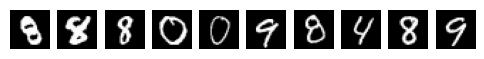

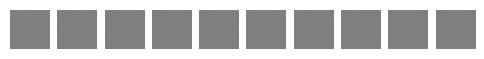

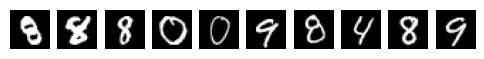

Autoencoder reconstruction error (infinity to 0): 3.872
Counterfactual prediction gain (0 to 1): 0.000
Sparsity (L1, infinity to 0): 0.003


  6%|▌         | 300/5100 [31:40<4:03:43,  3.05s/it]

183/183 [==============================] - 1s 6ms/step
Training iteration 300 at 2025-10-05 21:14:45.357817


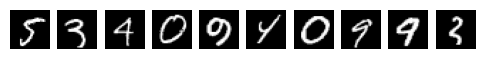

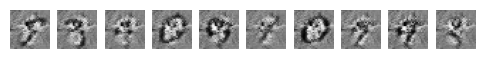

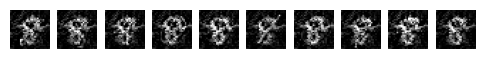

Autoencoder reconstruction error (infinity to 0): 7.391
Counterfactual prediction gain (0 to 1): 0.842
Sparsity (L1, infinity to 0): 0.222


 12%|█▏        | 600/5100 [47:04<3:29:15,  2.79s/it]

183/183 [==============================] - 2s 11ms/step
Training iteration 600 at 2025-10-05 21:30:10.328489


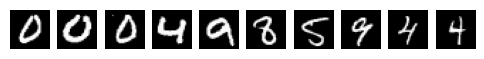

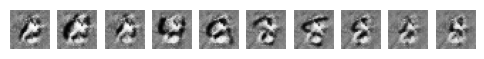

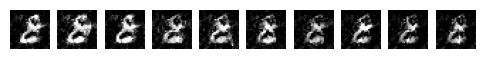

Autoencoder reconstruction error (infinity to 0): 7.333
Counterfactual prediction gain (0 to 1): 0.829
Sparsity (L1, infinity to 0): 0.227


 18%|█▊        | 900/5100 [1:02:36<4:42:15,  4.03s/it]

183/183 [==============================] - 1s 7ms/step
Training iteration 900 at 2025-10-05 21:45:43.019895


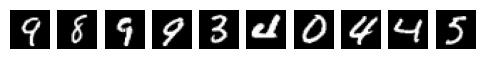

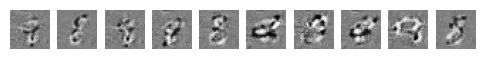

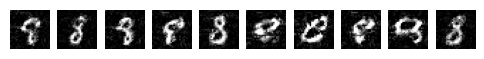

Autoencoder reconstruction error (infinity to 0): 5.862
Counterfactual prediction gain (0 to 1): 0.807
Sparsity (L1, infinity to 0): 0.161


 24%|██▎       | 1200/5100 [1:24:03<3:48:08,  3.51s/it]

183/183 [==============================] - 1s 5ms/step
Training iteration 1200 at 2025-10-05 22:07:07.138291


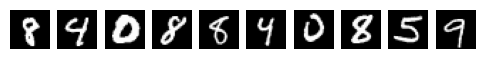

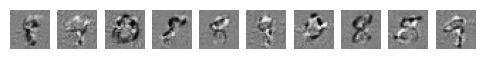

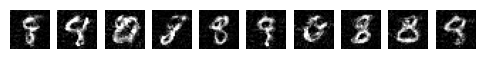

Autoencoder reconstruction error (infinity to 0): 5.337
Counterfactual prediction gain (0 to 1): 0.755
Sparsity (L1, infinity to 0): 0.144


 29%|██▉       | 1500/5100 [1:43:01<3:43:48,  3.73s/it]

183/183 [==============================] - 1s 7ms/step
Training iteration 1500 at 2025-10-05 22:26:06.047790


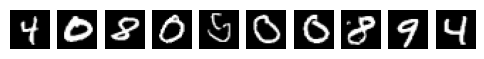

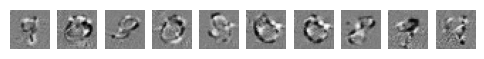

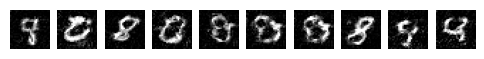

Autoencoder reconstruction error (infinity to 0): 5.015
Counterfactual prediction gain (0 to 1): 0.711
Sparsity (L1, infinity to 0): 0.127


 35%|███▌      | 1800/5100 [2:02:22<3:41:35,  4.03s/it]

183/183 [==============================] - 1s 6ms/step
Training iteration 1800 at 2025-10-05 22:45:27.000343


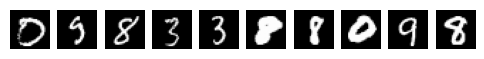

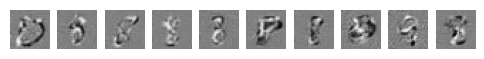

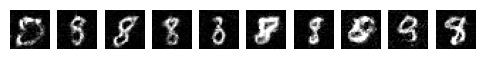

Autoencoder reconstruction error (infinity to 0): 5.070
Counterfactual prediction gain (0 to 1): 0.741
Sparsity (L1, infinity to 0): 0.130


 41%|████      | 2100/5100 [2:24:14<3:51:34,  4.63s/it]

183/183 [==============================] - 1s 8ms/step
Training iteration 2100 at 2025-10-05 23:07:20.142357


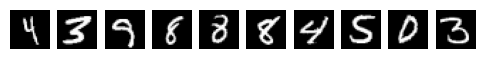

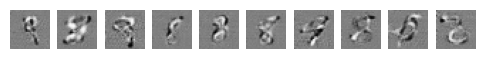

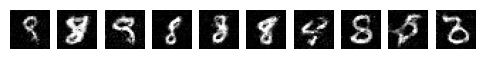

Autoencoder reconstruction error (infinity to 0): 4.958
Counterfactual prediction gain (0 to 1): 0.709
Sparsity (L1, infinity to 0): 0.122


 47%|████▋     | 2400/5100 [2:51:53<4:28:16,  5.96s/it]

183/183 [==============================] - 2s 11ms/step
Training iteration 2400 at 2025-10-05 23:35:04.187128


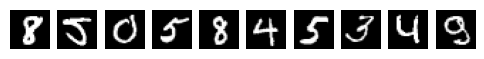

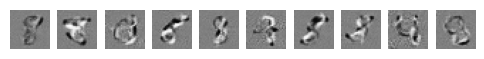

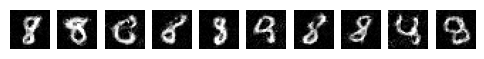

Autoencoder reconstruction error (infinity to 0): 4.878
Counterfactual prediction gain (0 to 1): 0.688
Sparsity (L1, infinity to 0): 0.120


 53%|█████▎    | 2700/5100 [3:20:48<4:04:52,  6.12s/it]

183/183 [==============================] - 2s 12ms/step
Training iteration 2700 at 2025-10-06 00:03:59.736384


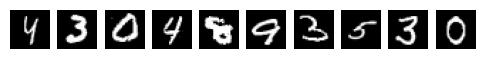

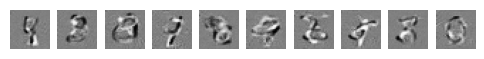

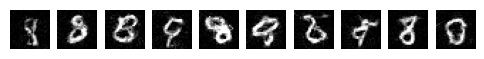

Autoencoder reconstruction error (infinity to 0): 4.704
Counterfactual prediction gain (0 to 1): 0.682
Sparsity (L1, infinity to 0): 0.119


 59%|█████▉    | 3000/5100 [3:50:10<3:23:07,  5.80s/it]

183/183 [==============================] - 2s 11ms/step
Training iteration 3000 at 2025-10-06 00:33:20.656353


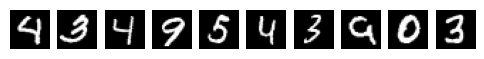

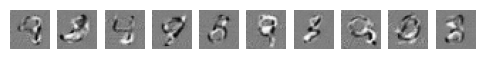

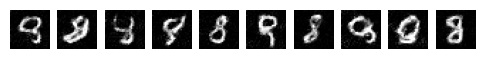

Autoencoder reconstruction error (infinity to 0): 4.747
Counterfactual prediction gain (0 to 1): 0.712
Sparsity (L1, infinity to 0): 0.119


 65%|██████▍   | 3300/5100 [4:20:25<2:59:16,  5.98s/it]

183/183 [==============================] - 2s 10ms/step
Training iteration 3300 at 2025-10-06 01:03:36.751022


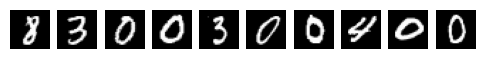

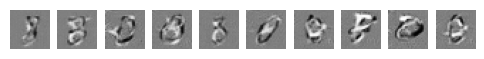

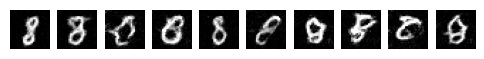

Autoencoder reconstruction error (infinity to 0): 4.749
Counterfactual prediction gain (0 to 1): 0.689
Sparsity (L1, infinity to 0): 0.116


 71%|███████   | 3600/5100 [4:51:27<2:32:11,  6.09s/it]

183/183 [==============================] - 2s 10ms/step
Training iteration 3600 at 2025-10-06 01:34:36.605140


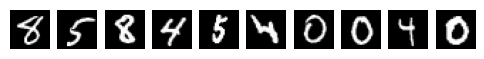

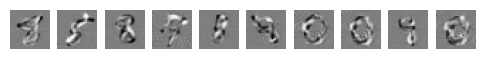

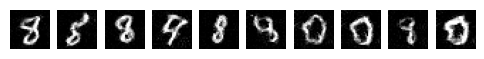

Autoencoder reconstruction error (infinity to 0): 4.733
Counterfactual prediction gain (0 to 1): 0.684
Sparsity (L1, infinity to 0): 0.114


 76%|███████▋  | 3900/5100 [5:23:03<2:07:57,  6.40s/it]

183/183 [==============================] - 2s 10ms/step
Training iteration 3900 at 2025-10-06 02:06:13.520846


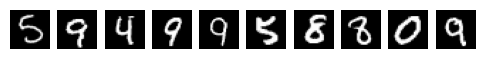

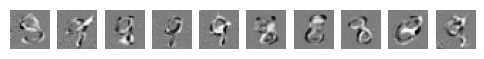

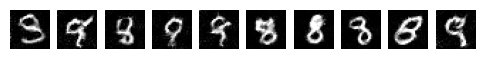

Autoencoder reconstruction error (infinity to 0): 4.632
Counterfactual prediction gain (0 to 1): 0.673
Sparsity (L1, infinity to 0): 0.114


 82%|████████▏ | 4200/5100 [5:56:00<1:40:17,  6.69s/it]

183/183 [==============================] - 3s 14ms/step
Training iteration 4200 at 2025-10-06 02:39:12.206595


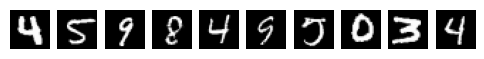

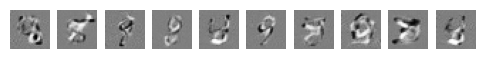

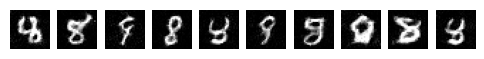

Autoencoder reconstruction error (infinity to 0): 4.541
Counterfactual prediction gain (0 to 1): 0.680
Sparsity (L1, infinity to 0): 0.109


 88%|████████▊ | 4500/5100 [6:30:36<1:08:31,  6.85s/it]

183/183 [==============================] - 2s 11ms/step
Training iteration 4500 at 2025-10-06 03:13:48.122260


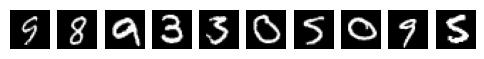

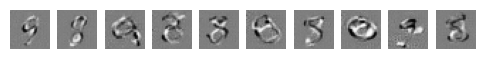

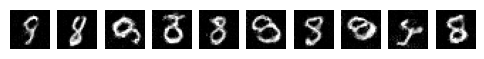

Autoencoder reconstruction error (infinity to 0): 4.471
Counterfactual prediction gain (0 to 1): 0.620
Sparsity (L1, infinity to 0): 0.109


 94%|█████████▍| 4800/5100 [7:07:05<37:03,  7.41s/it]  

183/183 [==============================] - 2s 11ms/step
Training iteration 4800 at 2025-10-06 03:50:16.045927


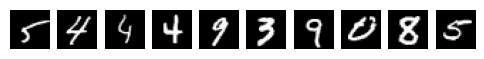

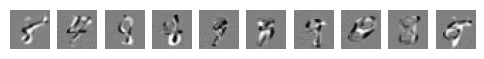

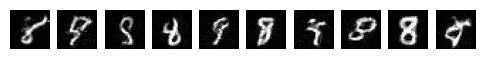

Autoencoder reconstruction error (infinity to 0): 4.435
Counterfactual prediction gain (0 to 1): 0.663
Sparsity (L1, infinity to 0): 0.108


100%|█████████▉| 5099/5100 [7:46:06<00:08,  8.23s/it]  

183/183 [==============================] - 2s 11ms/step
Training iteration 5099 at 2025-10-06 04:29:18.063917


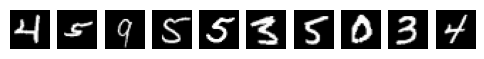

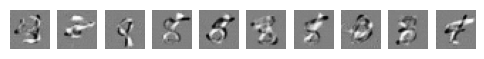

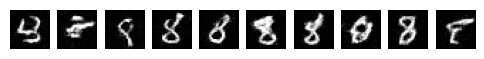

Autoencoder reconstruction error (infinity to 0): 4.481
Counterfactual prediction gain (0 to 1): 0.657
Sparsity (L1, infinity to 0): 0.109


100%|██████████| 5100/5100 [7:46:36<00:00,  5.49s/it]


In [73]:
method_name = "countergan"
countergan = train_countergan(2, 3, 5100, baseline_classifier, discriminator, generator, batches)

# Evaluation of CounterGAN

Load perts of CounteRGAN

In [229]:
models_save_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\cf_output\mnist\countergan_multi\checkpoints_7_trial2'

# generator_fname = 'generator_target8_iter_5099.keras' 
generator_fname = 'generator_target7_iter_5099.keras'
# discriminator_fname = 'discriminator_target8_iter_5099.keras' 
discriminator_fname = 'discriminator_target7_iter_5099.keras'

generator = load_model(osp.join(models_save_dir, generator_fname))
discriminator = load_model(osp.join(models_save_dir, discriminator_fname))

In [230]:
factuals, labels = [], []

for class_ind in [3, 4, 9]: #[3, 4, 9] # [0, 3, 4, 5, 9]
    indices = np.where(y_test == class_ind)[0]
    factuals.extend(x_test[indices])
    labels.extend([class_ind] * len(indices))
factuals = np.asarray(factuals)
labels = np.asarray(labels)

shuffled_indices = tf.random.shuffle(tf.range(labels.shape[0]))  # Generate shuffled indices
labels = tf.gather(labels, shuffled_indices)  # Reorder labels

# Shuffle images if needed to align with new label order
factuals = tf.expand_dims(tf.gather(factuals, shuffled_indices), axis=-1)
print('Total number of factual instances: ', factuals.shape[0])

Total number of factual instances:  3001


In [231]:
predictions = tf.argmax(baseline_classifier.predict(factuals, verbose=0), axis=1)
_, valid_indices = np.where([predictions == labels])

In [232]:
factuals = tf.gather(factuals, valid_indices)
labels = tf.gather(labels, valid_indices) 

## Robustness Evaluation

### Local Instability

In [233]:
from functools import reduce
from src.evaluation.local_instability import perturb_sample
from src.evaluation.local_instability import calculate_sparsity, calculate_ssim
from src.utils.visualization import plot_boxplot

In [234]:
cfes = generator.predict(factuals, verbose=0)

In [235]:
noise_levels = [0.005, 0.01, 0.015, 0.02, 0.025]
output_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\cf_output\mnist\countergan_multi'

In [236]:
factuals_pert = {}
pert_indices = {}

for noise_level in noise_levels:
    pert_sample = perturb_sample(factuals, n_samples=1, epsilon=noise_level, 
                                 type='uniform', channels_first=False)
    pert_sample = pert_sample.squeeze(1)
    factuals_pert[noise_level] = pert_sample
    # Check whether perturbed instances lead to the same class prediction
    predictions = tf.argmax(baseline_classifier.predict(pert_sample, verbose=0), axis=1)
    
    indices = np.where([predictions == labels])[1]
    pert_indices[noise_level] = indices

    print(f'Number of valid perturbed factuals for the added noise level {noise_level}: ', factuals_pert[noise_level].shape[0])

Number of valid perturbed factuals for the added noise level 0.005:  2938
Number of valid perturbed factuals for the added noise level 0.01:  2938
Number of valid perturbed factuals for the added noise level 0.015:  2938
Number of valid perturbed factuals for the added noise level 0.02:  2938
Number of valid perturbed factuals for the added noise level 0.025:  2938


In [237]:
n = 100
final_indices = reduce(np.intersect1d, list(pert_indices.values()))[:n]
factuals = tf.gather(factuals, final_indices) 
labels = tf.gather(labels, final_indices)

cfes = tf.gather(cfes, final_indices).numpy()
factuals_pert = {k : tf.gather(v, final_indices) for k, v in factuals_pert.items()}
cfes_pert =  {k: generator.predict(v, verbose=0) for k, v in factuals_pert.items()} 

In [238]:
cfes_pred = tf.argmax(baseline_classifier.predict(cfes, verbose=0), axis=1)
validity = len(np.where(cfes_pred == DESIRED_CLASS)[0]) / len(cfes)
print(f'Validity of the generated CFEs: {validity:.2%}')

Validity of the generated CFEs: 98.00%


In [194]:
validity_list = []
for noise_level in noise_levels:
    cfes_pert_pred = tf.argmax(baseline_classifier.predict(cfes_pert[noise_level], verbose=0), axis=1)
    validity = len(np.where(cfes_pert_pred == DESIRED_CLASS)[0]) / len(cfes)
    print(f'Validity of the generated CFEs under the noise level {noise_level}: {validity:.2%}')
    
    validity_list.append(validity)

with open(osp.join(output_dir, f'mnist_{DESIRED_CLASS}_validity.pkl'), 'wb') as f:
    pickle.dump(validity_list, f)

Validity of the generated CFEs under the noise level 0.005: 100.00%
Validity of the generated CFEs under the noise level 0.01: 100.00%
Validity of the generated CFEs under the noise level 0.015: 100.00%
Validity of the generated CFEs under the noise level 0.02: 100.00%
Validity of the generated CFEs under the noise level 0.025: 100.00%


In [195]:
# Check for the bounded noise

for noise_level in noise_levels:
    # diffs = np.abs(factuals - factuals_pert[noise_level])
    diffs = np.linalg.norm((factuals - factuals_pert[noise_level]).reshape(-1, 1), ord=np.Inf)
    print('Maximum difference between original and perturbed factuals for the noise level {:.2f}: {}'.format(noise_level, diffs))

Maximum difference between original and perturbed factuals for the noise level 0.01: 0.004999810722101217
Maximum difference between original and perturbed factuals for the noise level 0.01: 0.009999631321771977
Maximum difference between original and perturbed factuals for the noise level 0.01: 0.014999988075246891
Maximum difference between original and perturbed factuals for the noise level 0.02: 0.019999922695310996
Maximum difference between original and perturbed factuals for the noise level 0.03: 0.024999593218614967


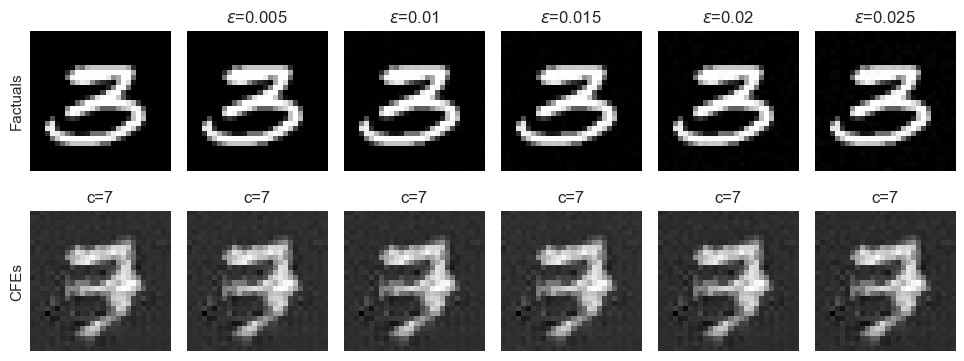

In [239]:
plt.style.use("seaborn-v0_8")

ind = 30
factuals_pert_list = [factuals_pert[noise_level][ind] for noise_level in noise_levels]
cfes_pert_list = [cfes_pert[noise_level][ind] for noise_level in noise_levels]

factuals_vis = [factuals[ind]] + factuals_pert_list #[factuals[0]] +
cfes_vis = [cfes[ind]] + cfes_pert_list #[cfes[0]] + 

n_rows = 2
n_cols = len(factuals_vis)

_, axs = plt.subplots(n_rows, n_cols, figsize=(10, 4), sharex=True, sharey=True)
for j in range(n_cols):
    axs[0, j].imshow(factuals_vis[j] , cmap="gray")
    if noise_levels and j > 0:
        noise = noise_levels[j-1]
        axs[0, j].set_title("$\\epsilon$={}".format(noise))

    axs[1, j].imshow(cfes_vis[j], cmap="gray")
    pred = tf.argmax(baseline_classifier.predict(tf.expand_dims(cfes_vis[j], axis=0), verbose=0), axis=1).numpy()
    axs[1, j].set_title(f'c={DESIRED_CLASS if pred == DESIRED_CLASS else pred[0]}')
    
    if j == 0:
        axs[0, j].set_ylabel('Factuals')
        axs[1, j].set_ylabel('CFEs')

plt.tight_layout()
plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[]);
# plt.savefig(osp.join(output_dir, f'countergan_multi_{DESIRED_CLASS}_cfes.png'), dpi=300)
plt.show()

In [197]:
# Calculating L1 distance between the explanations of original and perturbed instances
l1_list = []
ssim_list = []


for i, noise_level in tqdm(enumerate(cfes_pert.keys())):
    l1_temp = []
    ssim_temp = []

    cfs_pert = cfes_pert[noise_level]

    for i in tqdm(range(cfes_pert[noise_level].shape[0])): 

        l1_distance = calculate_sparsity(cfes[i].flatten(), cfes_pert[noise_level][i].flatten()).item()
        l1_temp.append(l1_distance)

        ssim = calculate_ssim(torch.Tensor(cfes[i]).permute(2, 0, 1).unsqueeze(0), 
                              torch.Tensor(cfes_pert[noise_level][i]).permute(2, 0, 1).unsqueeze(0)).item()
        ssim_temp.append(ssim)

    print(f'Average Instability (L1) for the set of counterfactuals of size : {np.mean(l1_temp)}')    
    l1_list.append(l1_temp)
    
    print(f'Average SSIM for the set of counterfactuals of size : {np.mean(ssim_temp)}')    
    ssim_list.append(ssim_temp)

0it [00:00, ?it/s]

100%|██████████| 100/100 [00:00<00:00, 339.69it/s]
1it [00:00,  3.34it/s]

Average Instability (L1) for the set of counterfactuals of size : 1.3898840939998627
Average SSIM for the set of counterfactuals of size : 0.9996763956546784


100%|██████████| 100/100 [00:00<00:00, 780.21it/s]
2it [00:00,  4.92it/s]

Average Instability (L1) for the set of counterfactuals of size : 2.7582501554489136
Average SSIM for the set of counterfactuals of size : 0.9987496900558471


...

Average Instability (L1) for the set of counterfactuals of size : 4.106870503425598
Average SSIM for the set of counterfactuals of size : 0.9971169006824493


100%|██████████| 100/100 [00:00<00:00, 747.52it/s]
4it [00:00,  5.69it/s]

Average Instability (L1) for the set of counterfactuals of size : 5.460267791748047
Average SSIM for the set of counterfactuals of size : 0.9949664503335953


100%|██████████| 100/100 [00:00<00:00, 741.64it/s]
5it [00:00,  5.50it/s]

Average Instability (L1) for the set of counterfactuals of size : 6.818292756080627
Average SSIM for the set of counterfactuals of size : 0.9921740627288819


In [158]:
with open(osp.join(output_dir, f'mnist_{DESIRED_CLASS}_li_l1.pkl'), 'wb') as f:
    pickle.dump(l1_list, f)

with open(osp.join(output_dir, f'mnist_{DESIRED_CLASS}_ssim.pkl'), 'wb') as f:
    pickle.dump(ssim_list, f)

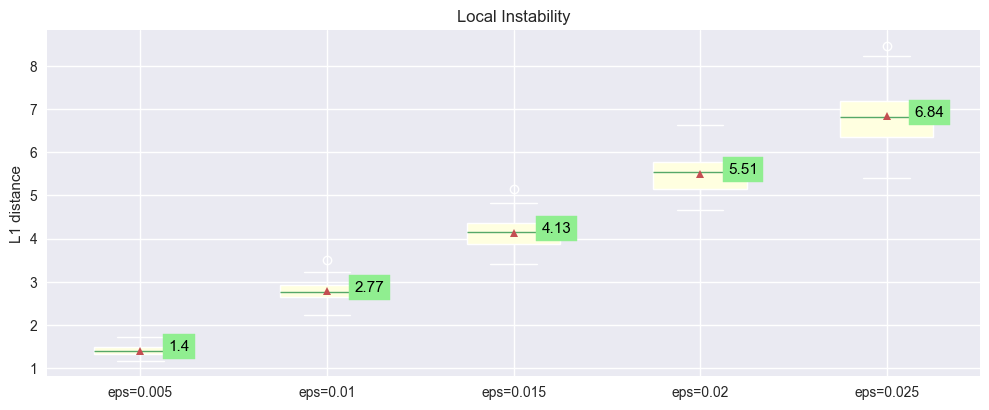

In [159]:
plt.style.use("seaborn-v0_8-notebook")
plt.rcParams['figure.figsize'] = [10, 4]

plot_boxplot(data=l1_list, mean_values=[np.round(np.mean(inst),2) for inst in l1_list],
             tick_labels=[f'eps={noise_level}' for noise_level in noise_levels],
             y_label='L1 distance', colors=['lightyellow'], title='Local Instability')

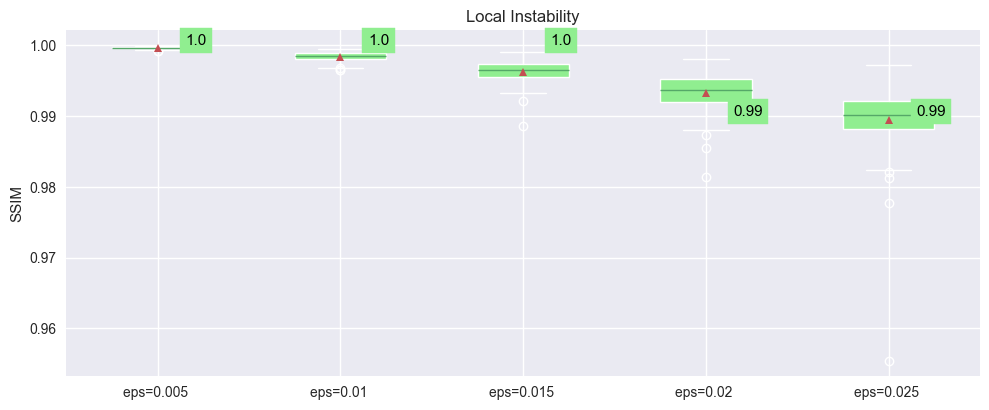

In [160]:
plot_boxplot(data=ssim_list, mean_values=[np.round(np.mean(inst),2) for inst in ssim_list],
             tick_labels=[f'eps={noise_level} ' for noise_level in noise_levels],

             y_label='SSIM', colors=['lightgreen'], title='Local Instability')

### Local Lipschitz Continuity

In [161]:
original_points = factuals
original_cfes = cfes
print("Are the lengths of initial points (factuals) and CFEs generated for them equal :", original_cfes.shape[0] == original_points.shape[0])


Are the lengths of initial points (factuals) and CFEs generated for them equal : True


In [162]:
noise_magnitude = 0.01

lip_estimates = []
n_samples = 30

for original_point, original_cfe in tqdm(zip(original_points[:30], original_cfes[:30])):

    neighbor_points = perturb_sample(original_point, n_samples=n_samples, 
                                     epsilon=noise_magnitude, type='uniform', 
                                     channels_first=False)  
    neighbor_points = neighbor_points.squeeze(0)  
    neighbor_cfes = generator.predict(neighbor_points, verbose=False)

    lip_estimate = 0
    for m, p in zip(neighbor_cfes, neighbor_points):
        num = np.linalg.norm((original_cfe - m).flatten(), ord=2) 
        denom = np.linalg.norm((original_point.numpy() - p).flatten(), ord=2)
        lip = num / denom
        lip_estimate = max(lip, lip_estimate)
 
    lip_estimates.append(lip_estimate)


30it [00:02, 10.42it/s]


In [163]:
with open(osp.join(output_dir, f'mnist_{DESIRED_CLASS}_lle.pkl'), 'wb') as f:
    pickle.dump(lip_estimates, f)

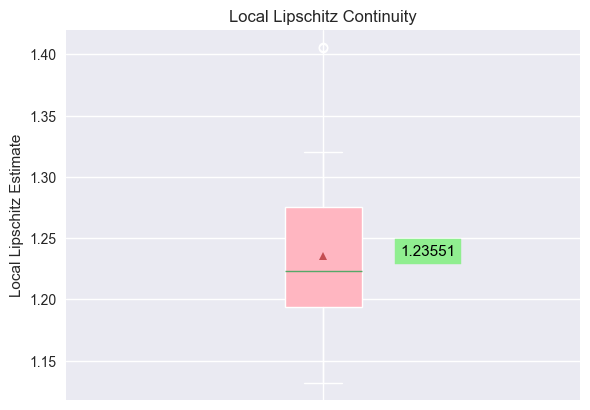

In [164]:
plt.rcParams['figure.figsize'] = [6, 4]
plot_boxplot(data=lip_estimates, mean_values=[np.round(np.mean(lip_estimates), 5)],
             tick_labels=[''],
             y_label='Local Lipschitz Estimate', colors=['lightpink'], title='Local Lipschitz Continuity')

### Invalidation Rate

Weights reinitialization

In [240]:
classifiers_weights_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\notebooks\experiments\mnist_classification\multi\checkpoints\mc_all_tf'

batch_size = 128

classifiers_list = []
for clf_fname in os.listdir(classifiers_weights_dir):
    cnn_perturbed = load_model(osp.join(classifiers_weights_dir, clf_fname), 
                            custom_objects={'CNNtf': CNNtf})
    classifiers_list.append(cnn_perturbed)

    logits = cnn_perturbed.predict(X_test)
    accuracy = (logits.argmax(axis=1) == y_test_red).mean()
    print(f"Classifier accuracy test: {accuracy:.3%}")

126/126 [==============================] - 1s 9ms/step
Classifier accuracy test: 98.163%
126/126 [==============================] - 1s 9ms/step
Classifier accuracy test: 98.461%
126/126 [==============================] - 1s 9ms/step
Classifier accuracy test: 98.436%
126/126 [==============================] - 1s 9ms/step
Classifier accuracy test: 96.649%
126/126 [==============================] - 1s 10ms/step
Classifier accuracy test: 97.741%
126/126 [==============================] - 1s 9ms/step
Classifier accuracy test: 98.560%
126/126 [==============================] - 1s 8ms/step
Classifier accuracy test: 98.709%
126/126 [==============================] - 1s 8ms/step
Classifier accuracy test: 98.461%
126/126 [==============================] - 1s 8ms/step
Classifier accuracy test: 98.436%
126/126 [==============================] - 1s 11ms/step
Classifier accuracy test: 98.362%


Evaluate IR only for the valid explanations for the baseline classifier

In [241]:
predictions = tf.argmax(baseline_classifier.predict(cfes, verbose=0), axis=1)
indices = np.where(predictions == DESIRED_CLASS)[0]
cfes_subsample = tf.gather(cfes, indices)

validity = len(np.where(predictions == DESIRED_CLASS)[0]) / len(cfes)
print(f'Validity of the generated CFEs for correctly classified instances: {validity:.2%}')

Validity of the generated CFEs for correctly classified instances: 98.00%


In [242]:
invalidation_rate_list = []
validity_list = []
total_cfs = cfes_subsample.shape[0]


for i, classifier in enumerate(classifiers_list):
    invalidation_rate = 0

    baseline_pred = tf.argmax(baseline_classifier.predict(cfes_subsample, verbose=0), axis=1)
    alternative_pred = tf.argmax(classifier.predict(cfes_subsample, verbose=0), axis=1)

    invalidation_rate_list.append(baseline_pred != alternative_pred)

inv_rate_array = np.asarray(invalidation_rate_list)
inv_rate_avg = inv_rate_array.mean(axis=0)
var_avg = 1 - inv_rate_avg
print("Average IR of the sample among {} models: {:.3f} ({:.3f})".format(len(classifiers_list), inv_rate_avg.mean(), inv_rate_avg.std()))
print("Average VaR of the sample among {} models: {:.3f} ({:.3f})".format(len(classifiers_list), var_avg.mean(), var_avg.std()))

Average IR of the sample among 10 models: 0.364 (0.370)
Average VaR of the sample among 10 models: 0.636 (0.370)


### Stability 

In [243]:
k = 1000
average_stability_list = []


for i, classifier in enumerate(classifiers_list):
    stability_list = []
    stability = 0

    original_logits = classifier.predict(cfes_subsample, verbose=0)
    # To calculate stability of only valid CFE, they need to be identified
    valid_cfs_ind = tf.where(original_logits.argmax(axis=1) == DESIRED_CLASS)[:, 0]
    print('Number of valid CFEs for the model {}: {}'.format(i, valid_cfs_ind.shape[0]))
    original_logits_subsample = tf.gather(original_logits, valid_cfs_ind)

    original_probabilities = tf.nn.softmax(original_logits_subsample, axis=-1)[:, DESIRED_CLASS]

    valid_cfs_subsample = tf.gather(cfes_subsample, valid_cfs_ind)
    cf_sample_pert = perturb_sample(valid_cfs_subsample, n_samples=k, 
                                    type='normal', epsilon=0, std=0.01)

    for j in range(original_probabilities.shape[0]):
        cf_sample_pert_j = cf_sample_pert[j] 
        logits = classifier.predict(cf_sample_pert_j, verbose=0)
        probabilities = tf.nn.softmax(logits, axis=-1)[:, DESIRED_CLASS]

        original_probabilities_i = tf.expand_dims(original_probabilities[j], axis=-1)
        model_variance = abs(original_probabilities_i - probabilities)
        stability = (probabilities - model_variance).numpy().mean()
    
        stability_list.append(stability)

    avg_i_stability = np.mean(stability_list)
    print(f'Average Stability of the model {i}: {round(avg_i_stability.item(), 3)} +- {round(np.std(stability_list).item(), 2)}')
    average_stability_list.append(avg_i_stability)

Number of valid CFEs for the model 0: 54
Average Stability of the model 0: 0.156 +- 0.03
Number of valid CFEs for the model 1: 65
Average Stability of the model 1: 0.175 +- 0.04
Number of valid CFEs for the model 2: 55
Average Stability of the model 2: 0.188 +- 0.04
Number of valid CFEs for the model 3: 67
Average Stability of the model 3: 0.174 +- 0.04
Number of valid CFEs for the model 4: 65
Average Stability of the model 4: 0.184 +- 0.05
Number of valid CFEs for the model 5: 49
Average Stability of the model 5: 0.178 +- 0.03
Number of valid CFEs for the model 6: 79
Average Stability of the model 6: 0.19 +- 0.04
Number of valid CFEs for the model 7: 47
Average Stability of the model 7: 0.182 +- 0.04
Number of valid CFEs for the model 8: 76
Average Stability of the model 8: 0.179 +- 0.04
Number of valid CFEs for the model 9: 66
Average Stability of the model 9: 0.169 +- 0.04


In [244]:
print(f"Average stability : {round(np.mean(average_stability_list).item(), 3)} +- {round(np.std(average_stability_list).item(), 3)}")

Average stability : 0.177 +- 0.009


### LOF

In [205]:
from sklearn.neighbors import LocalOutlierFactor

In [206]:
target_class_set = X_test[np.where(y_test_red==DESIRED_CLASS)[0]]
target_class_set.shape

TensorShape([974, 28, 28, 1])

In [207]:
lof = LocalOutlierFactor(n_neighbors=5, novelty=True, p=1)
lof.fit(target_class_set.reshape(target_class_set.shape[0], -1))

target_class_ascores = lof.score_samples(cfes.reshape(cfes.shape[0], -1))
target_class_classes = np.where(target_class_ascores < -1.1, -1, 1)
print('Average negative LOF (the lower values the more anomaluous): {:.3f} +- {:.3f}'.format(np.mean(target_class_ascores), 
                                                                                            np.std(target_class_ascores)))

Average negative LOF (the lower values the more anomaluous): -1.587 +- 0.227


In [208]:
lof = LocalOutlierFactor(n_neighbors=5, novelty=True, p=1)
lof.fit(X_test.reshape(X_test.shape[0], -1))

ascores = lof.score_samples(cfes.reshape(cfes.shape[0], -1))
aclasses = np.where(target_class_ascores < -1.2, -1, 1)
print('Average negative LOF (the lower values the more anomaluous): {:.3f} +- {:.3f}'.format(np.mean(ascores), np.std(ascores)))

Average negative LOF (the lower values the more anomaluous): -1.699 +- 0.272
